In [69]:
import pandas as  pd

In [70]:
df = pd.read_csv("loan_approval_dataset.csv")

In [71]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [73]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [74]:
df.columns =  df.columns.str.strip()

In [75]:
df.loan_status

0        Approved
1        Rejected
2        Rejected
3        Rejected
4        Rejected
          ...    
4264     Rejected
4265     Approved
4266     Rejected
4267     Approved
4268     Approved
Name: loan_status, Length: 4269, dtype: object

In [76]:
df.columns = df.columns.str.strip()
df['loan_status'] = df['loan_status'].str.strip()


In [77]:
print(df['loan_status'].value_counts())


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [78]:
df.loan_status = df.loan_status.apply(lambda x: 1 if x == 'Approved' else 0 )

In [79]:
print(df['loan_status'].value_counts())


loan_status
1    2656
0    1613
Name: count, dtype: int64


In [80]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [81]:
df = df.drop('loan_id', axis=1)

In [82]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [83]:
X = df.drop('loan_status' , axis=1)
y = df.loan_status

In [84]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [85]:
X = pd.get_dummies(X, columns=['education', 'self_employed'], drop_first=True, dtype=int)

In [86]:
print(df['loan_status'].value_counts())


loan_status
1    2656
0    1613
Name: count, dtype: int64


In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y , test_size=0.2 , random_state=42)
print("X_Train shape:" , X_train.shape)
print(y_train.shape)
X.head()

X_Train shape: (3415, 11)
(3415,)


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1


In [88]:
num_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 
            'cibil_score', 'residential_assets_value', 'commercial_assets_value', 
            'luxury_assets_value', 'bank_asset_value']

In [89]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X_train[num_cols] =scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [90]:
from tensorflow.keras import layers,models
import warnings
warnings.filterwarnings("ignore")

In [91]:
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [92]:
model.compile(optimizer = 'adam' , loss="binary_crossentropy",metrics=['accuracy'])

In [93]:
history = model.fit(X_train, y_train , epochs = 8,batch_size=32 , validation_split = 0.2 , verbose =1)

Epoch 1/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7668 - loss: 0.5390 - val_accuracy: 0.8843 - val_loss: 0.3955
Epoch 2/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8957 - loss: 0.3096 - val_accuracy: 0.9253 - val_loss: 0.2343
Epoch 3/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9173 - loss: 0.2303 - val_accuracy: 0.9283 - val_loss: 0.1910
Epoch 4/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9242 - loss: 0.2083 - val_accuracy: 0.9400 - val_loss: 0.1734
Epoch 5/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9308 - loss: 0.1941 - val_accuracy: 0.9473 - val_loss: 0.1611
Epoch 6/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9323 - loss: 0.1837 - val_accuracy: 0.9531 - val_loss: 0.1533
Epoch 7/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9348 - loss: 0.1751 - val_accuracy: 0.9546 - val_loss: 0.1459
Epoch 8/8
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9400 - loss: 0.1658 - val_accuracy: 0.9546 - val_loss:

In [94]:
test_loss, test_accuracy = model.evaluate(X_test ,y_test)
print(f"Loan Approval Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9274 - loss: 0.1658
Loan Approval Test Accuracy: 0.9274 (92.74%)


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


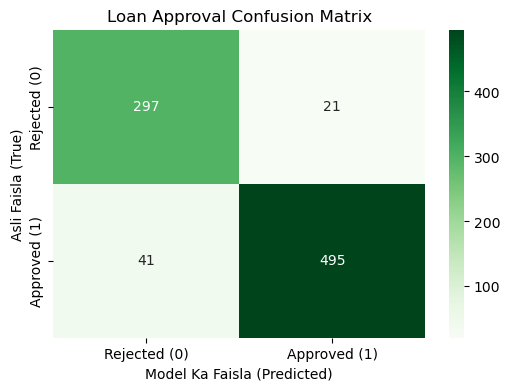


=== Model Ka Detail Scorecard ===
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       318
           1       0.96      0.92      0.94       536

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.92       854
weighted avg       0.93      0.93      0.93       854



In [95]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Test data par predictions nikalna (Probabilities)
y_pred_prob = model.predict(X_test)

# 2. Probability ko 0.5 ke threshold se binary (0 ya 1) me badalna
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Confusion Matrix banana
cm = confusion_matrix(y_test, y_pred)

# 4. Heatmap plot karna
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Model Ka Faisla (Predicted)')
plt.ylabel('Asli Faisla (True)')
plt.title('Loan Approval Confusion Matrix')
plt.show()

# 5. Detail Report Card Print karna
print("\n=== Model Ka Detail Scorecard ===")
print(classification_report(y_test, y_pred))


In [97]:
import pickle

# 1. Trained Deep Learning Model ko save karna (Keras format)
model.save('loan_model.keras')

# 2. Scaler ko save karna (Pickle format) - Yeh naye data ko scale karne ke liye zaroori hai
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Mubarak ho! Model ('loan_model.keras') aur Scaler ('scaler.pkl') kamyaabi se save ho gaye hain.")


Mubarak ho! Model ('loan_model.keras') aur Scaler ('scaler.pkl') kamyaabi se save ho gaye hain.
